In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/customerchurn_datavis/customer_churn_dataset-testing-master.csv')

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
df.shape

(64374, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,52.631497
1,47.368503


In [ ]:
df.groupby('Churn').mean(numeric_only=True)

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
Churn,,,,,,,,
0,22846.794959,41.132700,28.826481,16.042915,4.500753,12.453086,560.541956,15.521944
1,42566.027121,42.902404,35.515200,14.010593,6.400617,22.334897,519.336143,15.473191


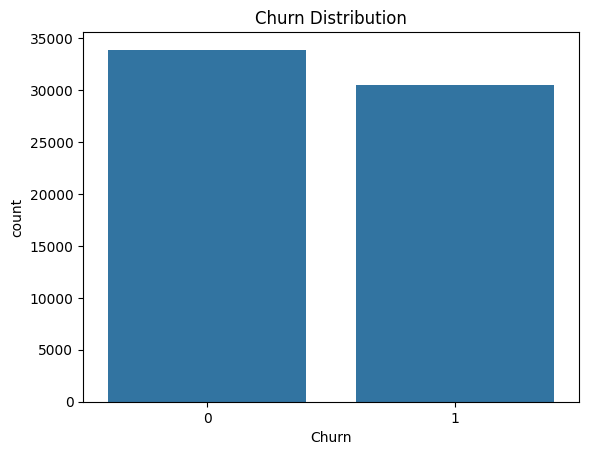

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

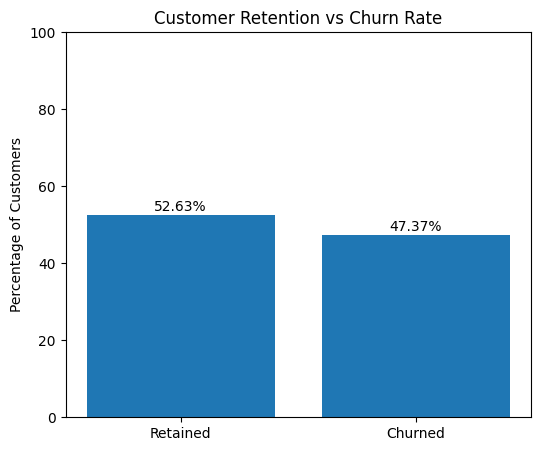

In [ ]:
import matplotlib.pyplot as plt

labels = ['Retained', 'Churned']
values = [retain_percent, churn_percent]

plt.figure(figsize=(6,5))
plt.bar(labels, values)

plt.ylabel('Percentage of Customers')
plt.title('Customer Retention vs Churn Rate')

plt.ylim(0,100)

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.show()

In [ ]:
df = df.drop('CustomerID', axis=1)

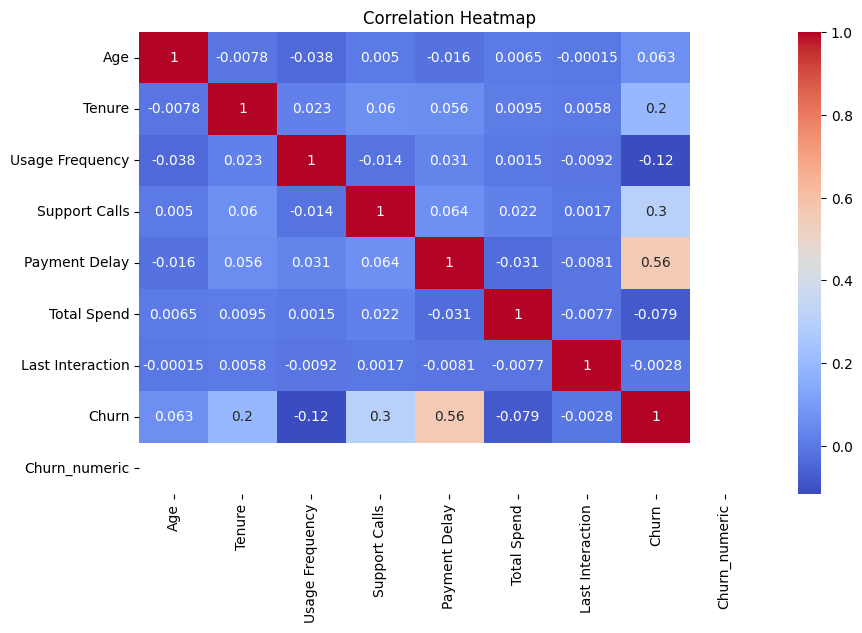

In [ ]:
df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print(df['Payment Delay'].describe())

count    64374.000000
mean        17.133952
std          8.852211
min          0.000000
25%         10.000000
50%         19.000000
75%         25.000000
max         30.000000
Name: Payment Delay, dtype: float64


In [ ]:

df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
Payment Delay,0.557386
Support Calls,0.304631
Tenure,0.195327
Age,0.063457
Last Interaction,-0.002818
Total Spend,-0.078867
Usage Frequency,-0.115098
Churn_numeric,NaN


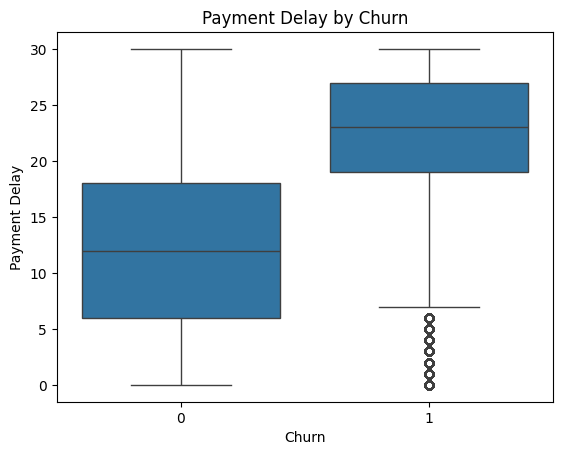

In [ ]:
sns.boxplot(x='Churn', y='Payment Delay', data=df)
plt.title("Payment Delay by Churn")
plt.show()

In [ ]:
df['Delay_Group'] = pd.cut(
    df['Payment Delay'],
    bins=[-1, 5, 15, 30],
    labels=['Low (0-5)', 'Medium (6-15)', 'High (16-30)']
)

In [ ]:
print(df['Delay_Group'].value_counts())

Delay_Group
High (16-30)     39204
Medium (6-15)    15807
Low (0-5)         9363
Name: count, dtype: int64


In [ ]:
print(df['Churn'].unique())

[1 0]


In [ ]:
delay_churn = df.groupby('Delay_Group')['Churn'].mean() * 100
print(delay_churn)

Delay_Group
Low (0-5)        10.189042
Medium (6-15)    10.052508
High (16-30)     71.293746
Name: Churn, dtype: float64


/tmp/ipython-input-958/1311666117.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_churn = df.groupby('Delay_Group')['Churn'].mean() * 100


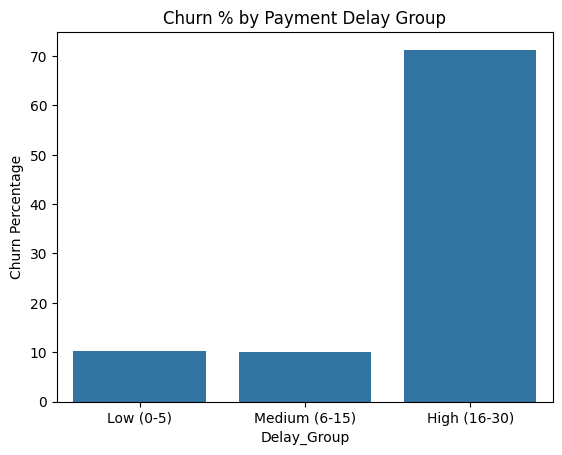

In [ ]:
sns.barplot(x=delay_churn.index, y=delay_churn.values)
plt.ylabel("Churn Percentage")
plt.title("Churn % by Payment Delay Group")
plt.show()

In [ ]:
print(df['Support Calls'].value_counts().sort_index())

Support Calls
0     4967
1     4929
2     4812
3     4723
4     5148
5     6657
6     6639
7     6599
8     6649
9     6664
10    6587
Name: count, dtype: int64


In [ ]:
support_churn = df.groupby('Support Calls')['Churn'].mean() * 100
print(support_churn)

Support Calls
0     24.219851
1     22.884967
2     23.150457
3     24.835909
4     31.837607
5     60.462671
6     60.611538
7     61.782088
8     60.956535
9     60.909364
10    60.695309
Name: Churn, dtype: float64


In [ ]:
df['Support_Group'] = pd.cut(
    df['Support Calls'],
    bins=[-1, 3, 4, df['Support Calls'].max()],
    labels=['Low (0-3)', 'Medium (4)', 'High (5+)']
)
support_group_churn = (
    df.groupby('Support_Group')['Churn']
      .mean()
      .mul(100)
      .round(2)
)

support_group_churn

/tmp/ipython-input-958/3723986050.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Support_Group')['Churn']


,Churn
Support_Group,
Low (0-3),23.77
Medium (4),31.84
High (5+),60.90


/tmp/ipython-input-958/972753539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  support_churn_grouped = df.groupby('Support_Group')['Churn'].mean() * 100


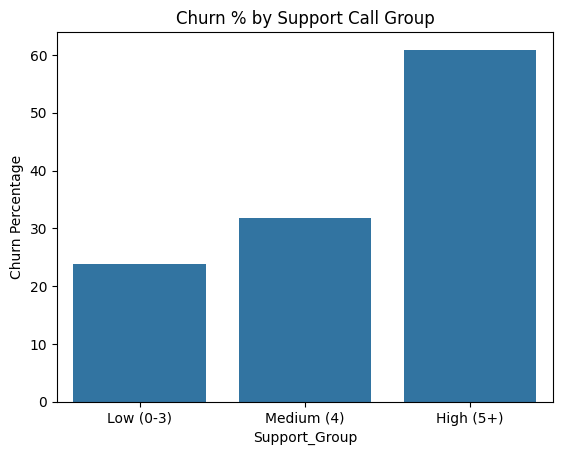

In [ ]:
support_churn_grouped = df.groupby('Support_Group')['Churn'].mean() * 100

sns.barplot(x=support_churn_grouped.index, y=support_churn_grouped.values)
plt.ylabel("Churn Percentage")
plt.title("Churn % by Support Call Group")
plt.show()

In [ ]:
risk_matrix = df.pivot_table(
    values='Churn',
    index='Support_Group',
    columns='Delay_Group',
    aggfunc='mean'
) * 100

/tmp/ipython-input-958/678501319.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  risk_matrix = df.pivot_table(


In [ ]:
risk_matrix = df.pivot_table(
    values='Churn',
    index='Support_Group',
    columns='Delay_Group',
    aggfunc='mean',
    observed=False
) * 100
print(risk_matrix)

Delay_Group    Low (0-5)  Medium (6-15)  High (16-30)
Support_Group                                        
Low (0-3)       2.858862       2.901212     40.939786
Medium (4)     13.099415      14.256619     46.702128
High (5+)      14.406943      13.737624     86.571806


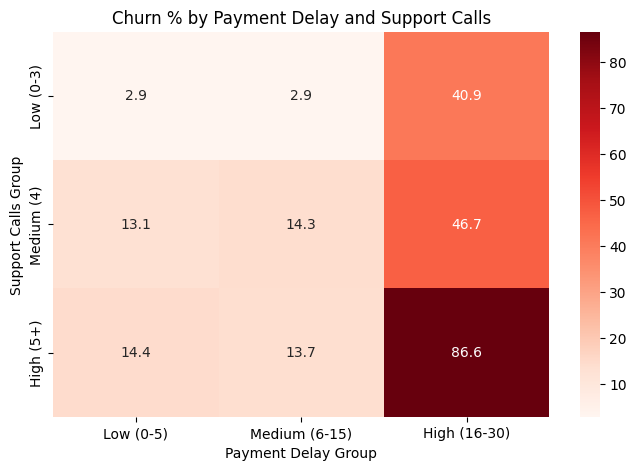

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Churn % by Payment Delay and Support Calls")
plt.ylabel("Support Calls Group")
plt.xlabel("Payment Delay Group")

plt.show()

In [ ]:
churn_percent = df['Churn'].mean() * 100
retain_percent = 100 - churn_percent

churn_percent, retain_percent

(np.float64(47.368502811694164), np.float64(52.631497188305836))